In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.metrics import mean_squared_error

In [2]:
df = pd.read_csv('Boston.csv')

In [3]:
df

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,0.06263,0.0,11.93,0,0.573,6.593,69.1,2.4786,1,273.0,21.0,391.99,9.67,22.4
502,0.04527,0.0,11.93,0,0.573,6.120,76.7,2.2875,1,273.0,21.0,396.90,9.08,20.6
503,0.06076,0.0,11.93,0,0.573,6.976,91.0,2.1675,1,273.0,21.0,396.90,5.64,23.9
504,0.10959,0.0,11.93,0,0.573,6.794,89.3,2.3889,1,273.0,21.0,393.45,6.48,22.0


In [4]:
X = df.drop(['MEDV'], axis=1)
y = df['MEDV']

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=0)

In [6]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((404, 13), (102, 13), (404,), (102,))

### Using R2 score as a performance metric of the fitted regression model

### Fit a fully grown tree

In [7]:
rt = DecisionTreeRegressor(random_state=0)
rt.fit(X=X_train, y=y_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [54]:
R2_train = rt.score(X_train, y_train)
R2_test = rt.score(X_test, y_test)
print('Training R2:', R2_train)
print('Test R2:', R2_test)

Training R2: 1.0
Test R2: 0.6019035496385025


In [8]:
'''
y_pred_train = rt.predict(X_train)
y_pred_test = rt.predict(X_test)

mse_train = mean_squared_error(y_train, y_pred_train)
mse_test = mean_squared_error(y_test, y_pred_test)
print('Training MSE:', mse_train)
print('Test MSE:', mse_test)
'''

Training MSE: 0.0
Test MSE: 32.41637254901961


In [9]:
print('Tree depth:', rt.tree_.max_depth)
print('Tree node count:', rt.tree_.node_count)

Tree depth: 20
Tree node count: 765


In [10]:
# plt.figure(figsize=(15,15))
# print(plot_tree(rt, filled=True, fontsize=8))

### Cost complexity Pruning

In [11]:
path = rt.cost_complexity_pruning_path(X_train, y_train)
# cost_complexity_pruning_path(X_train, y_train) gives you all possible values of the pruning parameter α along with 
# corresponding impurity scores, allowing  you to visualize or choose how much to prune your decision tree to balance bias and variance.

In [12]:
path

{'ccp_alphas': array([0.00000000e+00, 7.03507659e-17, 1.40701532e-16, 5.62806127e-16,
        1.12561225e-15, 2.25122451e-15, 1.23762376e-05, 1.23762376e-05,
        1.23762376e-05, 1.23762376e-05, 1.23762376e-05, 1.23762376e-05,
        1.23762376e-05, 1.23762376e-05, 1.23762376e-05, 1.23762376e-05,
        1.23762376e-05, 1.23762376e-05, 1.23762376e-05, 1.23762376e-05,
        1.23762376e-05, 1.23762376e-05, 1.23762376e-05, 1.23762376e-05,
        1.23762376e-05, 1.23762376e-05, 1.23762376e-05, 1.23762376e-05,
        1.23762376e-05, 1.23762376e-05, 1.23762376e-05, 1.65016502e-05,
        2.47524752e-05, 3.71287129e-05, 3.71287129e-05, 3.71287129e-05,
        3.71287129e-05, 4.95049505e-05, 4.95049505e-05, 4.95049505e-05,
        4.95049505e-05, 4.95049505e-05, 4.95049505e-05, 4.95049505e-05,
        4.95049505e-05, 4.95049505e-05, 4.95049505e-05, 4.95049505e-05,
        4.95049505e-05, 4.95049505e-05, 4.95049505e-05, 6.60066007e-05,
        6.60066007e-05, 7.42574257e-05, 1.03135314

In [13]:
ccp_alphas, impurities = path.ccp_alphas, path.impurities

In [14]:
len(ccp_alphas)

369

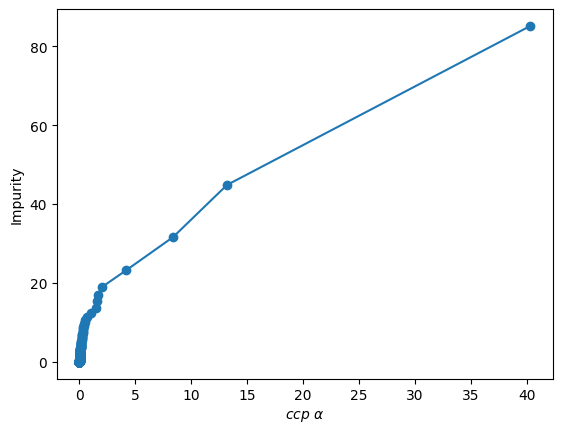

In [15]:
plt.plot(ccp_alphas, impurities, marker = 'o')
plt.xlabel(r'$ccp~\alpha$')
plt.ylabel('Impurity')
plt.show()

In [16]:
# Remove the last tree (only root), not useful for accuracy

ccp_alphas = np.unique(ccp_alphas)[:-1]

# We’re removing the last α, because it corresponds to a completely pruned 
# regression tree that predicts only the global mean(it always gives this same trivial output.) — not useful when comparing performance.
# It has maximum bias (underfits completely). It contributes no insight about features.

In [17]:
len(ccp_alphas)

346

In [18]:
#n_jobs controls how many CPU cores (parallel processes) scikit-learn should use to run cross-validation folds in parallel.
cv_r2 = []  # Store results
# Compute cross-validated avg MSE for each candidate ccp_alpha
for alpha in ccp_alphas:
    dt = DecisionTreeRegressor(random_state=0, ccp_alpha=alpha)
    scores = cross_val_score(dt, X_train, y_train, cv=KFold(5, shuffle=True, random_state=0),
                             scoring='r2', n_jobs=5)
    cv_r2.append(np.mean(scores))

In [19]:
len(cv_r2)

346

In [23]:
alph_cv = pd.DataFrame({'ccp_alpha':ccp_alphas , 'cv_R2':cv_r2})

In [24]:
alph_cv

,ccp_alpha,cv_R2
0,0.000000e+00,0.774434
1,7.035077e-17,0.774434
2,1.407015e-16,0.774434
3,5.628061e-16,0.774434
4,1.125612e-15,0.774434
...,...,...
341,1.673695e+00,0.753727
342,2.054679e+00,0.726662
343,4.203123e+00,0.674019
344,8.377055e+00,0.598085


In [22]:
# Choosing best alpha

best_alpha = ccp_alphas[np.argmax(cv_r2)]
print("Best alpha:", best_alpha)
print("maximum CV_R2:", np.max(cv_r2))

Best alpha: 0.2816648522367009
maximum CV_R2: 0.804677392317141


In [34]:
alph_cv['cv_R2'][alph_cv['ccp_alpha'] == best_alpha]

329    0.804677
Name: cv_R2, dtype: float64

Text(0, 0.5, 'Avg CV $R^2$')

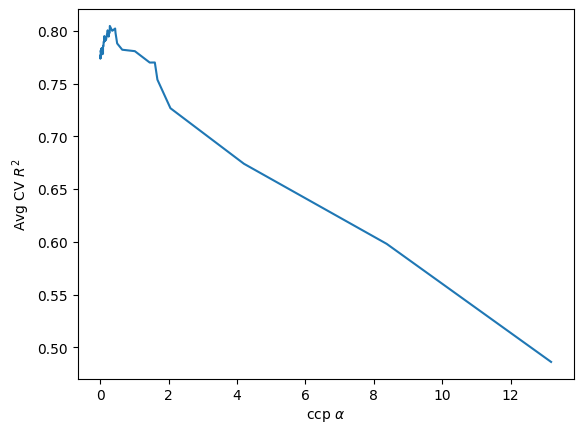

In [35]:
plt.plot(ccp_alphas, cv_r2)
plt.xlabel(r'ccp $\alpha$')
plt.ylabel(r'Avg CV $R^2$')

### Final Tree

In [36]:
# Fit final model with best alpha
final_tree = DecisionTreeRegressor(random_state=0, ccp_alpha=0.28167) # i.e. using ccp_alpha = best_alpha
final_tree.fit(X_train, y_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.28167


In [38]:
print('Final tree results')
print('Training R2:', final_tree.score(X_train, y_train))
print('Test R2:', final_tree.score(X_test, y_test))
print('Tree depth:', final_tree.tree_.max_depth)
print('Tree node count:', final_tree.tree_.node_count)

Final tree results
Training R2: 0.9096774390210188
Test R2: 0.6136061475824068
Tree depth: 6
Tree node count: 35


In [39]:
## Some diagrams

In [40]:
clfs = []
for alpha in ccp_alphas:
    clf = DecisionTreeRegressor(ccp_alpha=alpha, random_state=0)
    clf.fit(X_train, y_train)
    clfs.append(clf)
node_counts = [clf.tree_.node_count for clf in clfs]
depth = [clf.tree_.max_depth for clf in clfs]

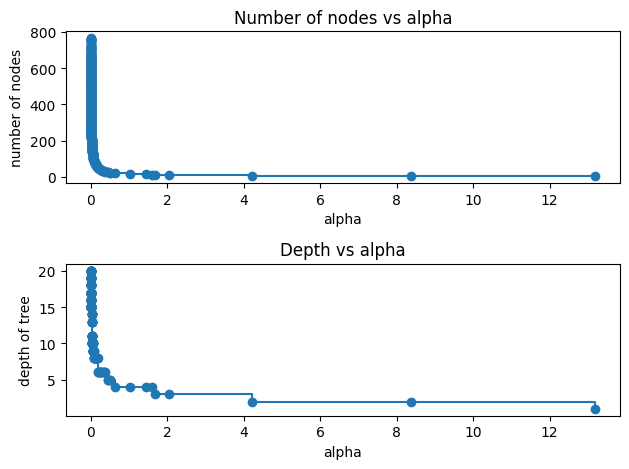

In [41]:
fig, ax = plt.subplots(2, 1)
ax[0].plot(ccp_alphas, node_counts, marker="o", drawstyle="steps-post")
ax[0].set_xlabel("alpha")
ax[0].set_ylabel("number of nodes")
ax[0].set_title("Number of nodes vs alpha")
ax[1].plot(ccp_alphas, depth, marker="o", drawstyle="steps-post")
ax[1].set_xlabel("alpha")
ax[1].set_ylabel("depth of tree")
ax[1].set_title("Depth vs alpha")
fig.tight_layout()

### Plotting train and test R2 for various prunned subtrees

In [42]:
train_scores = [clf.score(X_train, y_train) for clf in clfs]
test_scores = [clf.score(X_test, y_test) for clf in clfs]

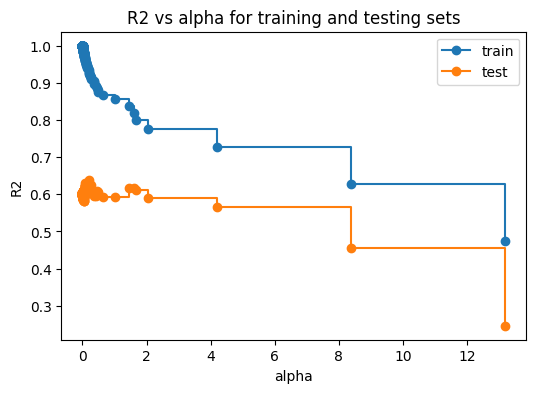

In [43]:
fig, ax = plt.subplots(figsize=(6,4))
ax.set_xlabel("alpha")
ax.set_ylabel("R2")
ax.set_title("R2 vs alpha for training and testing sets")
ax.plot(ccp_alphas, train_scores, marker="o", label="train", drawstyle="steps-post")
ax.plot(ccp_alphas, test_scores, marker="o", label="test", drawstyle="steps-post")
ax.legend()
plt.show()

In [50]:
AA = pd.DataFrame({'node_counts':node_counts,
                   'depth': depth,
                   'train_scores': train_scores,
                   'test_scores': test_scores,
                   'ccp_alphas': ccp_alphas,
                   'cv':cv_r2})
AA.iloc[np.append(0,np.arange(325,335)), :]
# or just print AA

,node_counts,depth,train_scores,test_scores,ccp_alphas,cv
0,765,20,1.000000,0.601904,0.000000,0.774434
325,43,6,0.922244,0.619354,0.241179,0.797221
326,41,6,0.919332,0.618447,0.247951,0.794572
327,39,6,0.916257,0.625877,0.261818,0.798288
328,37,6,0.912986,0.615447,0.278516,0.798288
329,35,6,0.909677,0.613606,0.281665,0.804677
330,33,6,0.905563,0.606412,0.350296,0.800135
331,31,6,0.901380,0.607506,0.356146,0.800135
332,29,6,0.897177,0.596533,0.357876,0.800135
333,27,5,0.892037,0.594205,0.437659,0.802214


### Linear regression

In [51]:
from sklearn.linear_model import LinearRegression

In [52]:
model = LinearRegression()
model.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [53]:
print('Linear regression scores')
print('Train R2 score: ', model.score(X_train, y_train))
print('Test R2 score: ', model.score(X_test, y_test))

Linear regression scores
Train R2 score:  0.7730135569264234
Test R2 score:  0.5892223849182503


In [56]:
data_scores = {
    'R2 train': [R2_train, final_tree.score(X_train, y_train) , model.score(X_train, y_train)],
    'R2 test': [R2_test, final_tree.score(X_test, y_test), model.score(X_test, y_test)]
}

datasc_df = pd.DataFrame(data_scores, index=['Fully grown tree', 'Final Pruned Tree', 'Multiple Linear Regression'])
print(datasc_df)

                            R2 train   R2 test
Fully grown tree            1.000000  0.601904
Final Pruned Tree           0.909677  0.613606
Multiple Linear Regression  0.773014  0.589222


### Using mean squared error as the performance metric of the fitted regression model.

In [57]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.metrics import mean_squared_error

In [58]:
df = pd.read_csv('Boston.csv')

In [59]:
df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2


In [61]:
X = df.drop(['MEDV'], axis=1)
y = df['MEDV']

In [62]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=0)

In [63]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((404, 13), (102, 13), (404,), (102,))

### Fit a fully grown tree

In [64]:
rt = DecisionTreeRegressor(random_state=0)
rt.fit(X=X_train, y=y_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [65]:
y_pred_train = rt.predict(X_train)
y_pred_test = rt.predict(X_test)

mse_train = mean_squared_error(y_train, y_pred_train)
mse_test = mean_squared_error(y_test, y_pred_test)
print('Training MSE:', mse_train)
print('Test MSE:', mse_test)

Training MSE: 0.0
Test MSE: 32.41637254901961


In [66]:
print('Tree depth:', rt.tree_.max_depth)
print('Tree node count:', rt.tree_.node_count)

Tree depth: 20
Tree node count: 765


In [67]:
# plt.figure(figsize=(15,15))
# print(plot_tree(rt, filled=True, fontsize=8))

### Cost complexity Pruning

In [68]:
path = rt.cost_complexity_pruning_path(X_train, y_train)

In [69]:
ccp_alphas, impurities = path.ccp_alphas, path.impurities

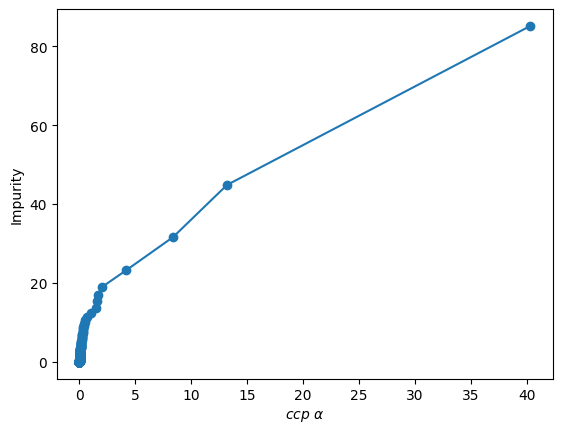

In [70]:
plt.plot(ccp_alphas, impurities, marker = 'o')
plt.xlabel(r'$ccp~\alpha$')
plt.ylabel('Impurity')
plt.show()

In [71]:
# Removing the last tree (only root), not useful for accuracy
ccp_alphas = np.unique(ccp_alphas)[:-1]
# ccp_alphas

In [84]:
len(ccp_alphas)

346

In [72]:
cv_mse = []  # Store results
# Computing cross-validated avg MSE for each candidate ccp_alpha
for alpha in ccp_alphas:
    dt = DecisionTreeRegressor(random_state=0, ccp_alpha=alpha)
    scores = cross_val_score(dt, X_train, y_train, cv=KFold(5, shuffle=True, random_state=0),
                             scoring='neg_mean_squared_error', n_jobs=5)
    cv_mse.append(np.mean(-scores)) # since scikit assigns -ve to mse values to indicate higher the better i.e. less negative MSE is higher and better

In [73]:
# Choose best alpha
best_alpha = ccp_alphas[np.argmin(cv_mse)]
print("Best alpha:", best_alpha)
print("Minimum CV_MSE:", np.min(cv_mse))

Best alpha: 0.2816648522367009
Minimum CV_MSE: 16.469848261986094


Text(0, 0.5, 'Avg CV MSE')

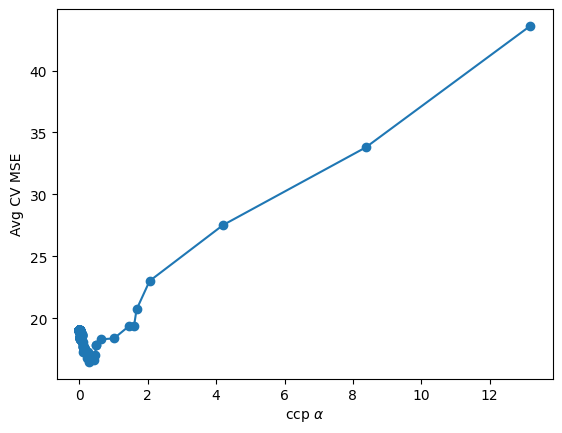

In [74]:
plt.plot(ccp_alphas, cv_mse, marker = 'o')
plt.xlabel(r'ccp $\alpha$')
plt.ylabel('Avg CV MSE')

### Final Tree

In [75]:
# Fitting final model with best alpha
final_tree = DecisionTreeRegressor(random_state=0, ccp_alpha=0.28167)
final_tree.fit(X_train, y_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.28167


In [76]:
y_pred_train = final_tree.predict(X_train)
y_pred_test = final_tree.predict(X_test)

mse_train = mean_squared_error(y_train, y_pred_train)
mse_test = mean_squared_error(y_test, y_pred_test)
print('Training MSE:', mse_train)
print('Test MSE:', mse_test)

Training MSE: 7.690398861865073
Test MSE: 31.463448265478487


In [77]:
print('Tree depth:', final_tree.tree_.max_depth)
print('Tree node count:', final_tree.tree_.node_count)

Tree depth: 6
Tree node count: 35


### Some diagrams

In [78]:
clfs = []
for alpha in ccp_alphas:
    clf = DecisionTreeRegressor(ccp_alpha=alpha, random_state=0)
    clf.fit(X_train, y_train)
    clfs.append(clf)

In [79]:
node_counts = [clf.tree_.node_count for clf in clfs]
depth = [clf.tree_.max_depth for clf in clfs]

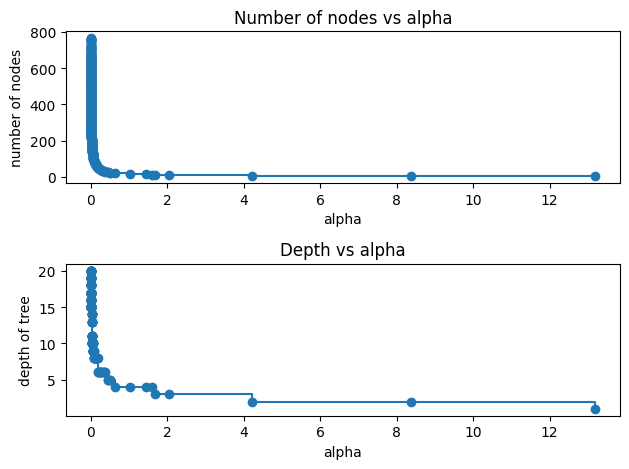

In [80]:
fig, ax = plt.subplots(2, 1)
ax[0].plot(ccp_alphas, node_counts, marker="o", drawstyle="steps-post")
ax[0].set_xlabel("alpha")
ax[0].set_ylabel("number of nodes")
ax[0].set_title("Number of nodes vs alpha")
ax[1].plot(ccp_alphas, depth, marker="o", drawstyle="steps-post")
ax[1].set_xlabel("alpha")
ax[1].set_ylabel("depth of tree")
ax[1].set_title("Depth vs alpha")
fig.tight_layout()

### Plotting train and test MSE for various prunned subtrees

In [81]:
train_scores = [mean_squared_error(y_train, clf.predict(X_train)) for clf in clfs]
test_scores = [mean_squared_error(y_test, clf.predict(X_test)) for clf in clfs]

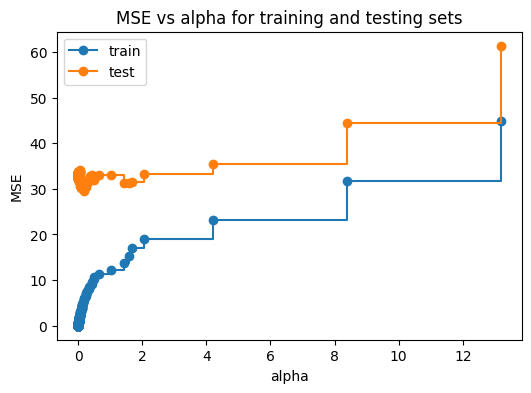

In [82]:
fig, ax = plt.subplots(figsize=(6,4))
ax.set_xlabel("alpha")
ax.set_ylabel("MSE")
ax.set_title("MSE vs alpha for training and testing sets")
ax.plot(ccp_alphas, train_scores, marker="o", label="train", drawstyle="steps-post")
ax.plot(ccp_alphas, test_scores, marker="o", label="test", drawstyle="steps-post")
ax.legend()
plt.show()

In [83]:
AA = pd.DataFrame({'node_counts':node_counts,
                   'depth': depth,
                   'train_mses': train_scores,
                   'test_mses': test_scores,
                   'ccp_alphas': ccp_alphas,
                   'cv':cv_mse})
AA.iloc[np.append(0,np.arange(325,335)), :]
# or simply print AA

,node_counts,depth,train_mses,test_mses,ccp_alphas,cv
0,765,20,0.000000,32.416373,0.000000,19.029993
325,43,6,6.620449,30.995428,0.241179,17.066365
326,41,6,6.868400,31.069240,0.247951,17.300589
327,39,6,7.130218,30.464244,0.261818,16.990586
328,37,6,7.408734,31.313530,0.278516,16.990586
329,35,6,7.690399,31.463448,0.281665,16.469848
330,33,6,8.040695,32.049284,0.350296,16.842377
331,31,6,8.396841,31.960181,0.356146,16.842377
332,29,6,8.754717,32.853693,0.357876,16.842377
333,27,5,9.192376,33.043214,0.437659,16.645893


### Linear regression

In [86]:
from sklearn.linear_model import LinearRegression

In [87]:
model = LinearRegression()
model.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [88]:
print('Linear regression Scores')
print('Train MSE: ', mean_squared_error(y_train, model.predict(X_train)))
print('Test MSE: ', mean_squared_error(y_test, model.predict(X_test)))

Linear regression Scores
Train MSE:  19.326470203585725
Test MSE:  33.44897999767657


In [91]:
data_mse_scores = {
    'Train MSE': [0.0, 7.69039 , 19.32647],
    'Test MSE': [32.41637,  31.46344, 33.44897]
}

datamse_df = pd.DataFrame(data_mse_scores, index=['Fully grown tree', 'Final Pruned Tree', 'Multiple Linear Regression'])
print(datamse_df)

                            Train MSE  Test MSE
Fully grown tree              0.00000  32.41637
Final Pruned Tree             7.69039  31.46344
Multiple Linear Regression   19.32647  33.44897


In [92]:
# So we see that Final Pruned Tree has performed better than the other 2 in terms of both the R2 and MSE performance metrices.